In [2]:
# Required Libraries
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB1
from tensorflow.keras.optimizers import Adam

2026-06-14 22:15:33.444301: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781475333.672021      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781475333.735643      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781475334.267374      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781475334.267417      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781475334.267419      58 computation_placer.cc:177] computation placer alr

In [3]:
# Path to the Kvasir dataset
data_path = "/kaggle/input/datasets/meetnagadia/kvasir-dataset/kvasir-dataset"

# Get the list of class folders
classes = os.listdir(data_path)

# Display the available classes
print(classes)

['dyed-lifted-polyps', 'normal-z-line', 'dyed-resection-margins', 'normal-pylorus', 'normal-cecum', 'polyps', 'ulcerative-colitis', 'esophagitis']


In [4]:
# Display the number of images in each class
for cls in classes:
    print(cls, ":", len(os.listdir(os.path.join(data_path, cls))))

dyed-lifted-polyps : 500
normal-z-line : 500
dyed-resection-margins : 500
normal-pylorus : 500
normal-cecum : 500
polyps : 500
ulcerative-colitis : 500
esophagitis : 500


In [5]:
# Define image size and batch size for data loading
img_size = (224, 224)
batch_size = 32

# Create the training dataset (80% of the data)
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

# Create the validation dataset (20% of the data)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

# Get the total number of validation batches
val_batches = tf.data.experimental.cardinality(val_ds)

# Split the validation dataset into validation and test sets
test_ds = val_ds.take(val_batches // 2)
val_ds = val_ds.skip(val_batches // 2)

# Display the number of batches in each dataset
print("Train batches:", tf.data.experimental.cardinality(train_ds))
print("Validation batches:", tf.data.experimental.cardinality(val_ds))
print("Test batches:", tf.data.experimental.cardinality(test_ds))

# Retrieve and display class names
class_names = train_ds.class_names
print("Classes:", class_names)

Found 4000 files belonging to 8 classes.
Using 3200 files for training.


I0000 00:00:1781475350.253146      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781475350.259880      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 4000 files belonging to 8 classes.
Using 800 files for validation.
Train batches: tf.Tensor(100, shape=(), dtype=int64)
Validation batches: tf.Tensor(13, shape=(), dtype=int64)
Test batches: tf.Tensor(12, shape=(), dtype=int64)
Classes: ['dyed-lifted-polyps', 'dyed-resection-margins', 'esophagitis', 'normal-cecum', 'normal-pylorus', 'normal-z-line', 'polyps', 'ulcerative-colitis']


In [6]:
# Enable automatic optimization of data loading
AUTOTUNE = tf.data.AUTOTUNE

# Cache, shuffle, and prefetch the training dataset for better performance
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)

# Cache and prefetch the validation dataset
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# Cache and prefetch the test dataset
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [7]:
# Display the shape of one batch of images and labels
for images, labels in train_ds.take(1):
    print(images.shape)
    print(labels.shape)

(32, 224, 224, 3)
(32,)


In [8]:
# Apply data augmentation techniques to improve model generalization
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2)
])

# Preprocessing function for EfficientNet
preprocess = tf.keras.applications.efficientnet.preprocess_input

# Load the pre-trained EfficientNetB1 model without the classification head
base_model = EfficientNetB1(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# Enable fine-tuning of the pre-trained model
base_model.trainable = True

# Freeze all layers except the last 80 layers
for layer in base_model.layers[:-80]:
    layer.trainable = False

# Build the complete classification model
model = models.Sequential([
    data_augmentation,
    layers.Lambda(preprocess),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(8, activation='softmax')
])

# Compile the model with optimizer, loss function, and evaluation metric
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display the model architecture
model.summary()

27018416/27018416 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb1 (Functional)     │ (None, 7, 7, 1280)     │     6,575,239 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,575,239 (25.08 MB)

 Trainable params: 4,678,416 (17.85 MB)

 Non-trainable params: 1,896,823 (7.24 MB)

In [9]:
# Reduce the learning rate when validation loss stops improving
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    verbose=1
)

# Stop training early and restore the best model weights
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

In [10]:
# Train the model using the training dataset and validate on the validation dataset
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[lr_scheduler, early_stop]
)

Epoch 1/20


E0000 00:00:1781475394.101434      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_1_1/efficientnetb1_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1781475397.763022     138 cuda_dnn.cc:529] Loaded cuDNN version 91002


100/100 ━━━━━━━━━━━━━━━━━━━━ 51s 225ms/step - accuracy: 0.5556 - loss: 1.2681 - val_accuracy: 0.7837 - val_loss: 0.7309 - learning_rate: 1.0000e-04
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 141ms/step - accuracy: 0.8059 - loss: 0.5304 - val_accuracy: 0.8389 - val_loss: 0.4436 - learning_rate: 1.0000e-04
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 143ms/step - accuracy: 0.8562 - loss: 0.3856 - val_accuracy: 0.8558 - val_loss: 0.3661 - learning_rate: 1.0000e-04
Epoch 4/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 142ms/step - accuracy: 0.8888 - loss: 0.2956 - val_accuracy: 0.8702 - val_loss: 0.3945 - learning_rate: 1.0000e-04
Epoch 5/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 145ms/step - accuracy: 0.9097 - loss: 0.2501 - val_accuracy: 0.8774 - val_loss: 0.3651 - learning_rate: 1.0000e-04
Epoch 6/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 147ms/step - accuracy: 0.9131 - loss: 0.2175 - val_accuracy: 0.8798 - val_loss: 0.3765 - learning_rate: 1.0000e-04
Epoch 7/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - a

In [11]:
# Evaluate the trained model on the test dataset
test_loss, test_acc = model.evaluate(test_ds)

# Display the test accuracy
print("Test Accuracy:", test_acc)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - accuracy: 0.8854 - loss: 0.3212
Test Accuracy: 0.8854166865348816


In [12]:
# Get and display the sorted list of class names
class_names = sorted(os.listdir(data_path))
print(class_names)

['dyed-lifted-polyps', 'dyed-resection-margins', 'esophagitis', 'normal-cecum', 'normal-pylorus', 'normal-z-line', 'polyps', 'ulcerative-colitis']


In [13]:
# Predict the class of an input image
def predict_image(img_path, model, class_names):
    from tensorflow.keras.preprocessing import image
    import numpy as np

    # Load and resize the image
    img = image.load_img(img_path, target_size=(224, 224))

    # Convert the image to an array and add a batch dimension
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    # Generate predictions
    preds = model.predict(img_array)

    # Get the predicted class and confidence score
    pred_index = np.argmax(preds[0])
    confidence = preds[0][pred_index]

    # Retrieve the class name
    pred_class = class_names[pred_index]

    return pred_class, confidence, img_array

In [14]:
# Select a class folder
class_name = "esophagitis"
folder = os.path.join(data_path, class_name)

# Select an image from the class folder
img_name = os.listdir(folder)[199]
img_path = os.path.join(folder, img_name)

# Display the image path
print(img_path)

/kaggle/input/datasets/meetnagadia/kvasir-dataset/kvasir-dataset/esophagitis/4abadec7-dfa0-4e44-a43f-473caf5bc2f3.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


(np.float64(-0.5), np.float64(1279.5), np.float64(1023.5), np.float64(-0.5))

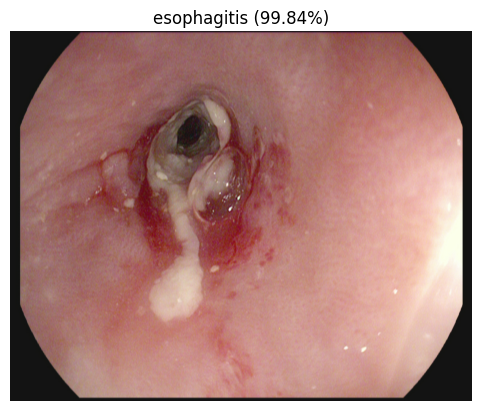

In [15]:
# Specify the image path for prediction
img_path = "/kaggle/input/datasets/meetnagadia/kvasir-dataset/kvasir-dataset/esophagitis/4abadec7-dfa0-4e44-a43f-473caf5bc2f3.jpg"

# Predict the image class and confidence score
pred_class, conf, img_array = predict_image(img_path, model, class_names)

# Load the image using OpenCV
img = cv2.imread(img_path)

# Convert the image from BGR to RGB format for visualization
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Display the image with the predicted class and confidence score
plt.imshow(img)
plt.title(f"{pred_class} ({conf*100:.2f}%)")
plt.axis("off")

# **Grad-CAM**

In [16]:
# Retrieve the EfficientNetB1 base model from the trained model
base_model = model.get_layer("efficientnetb1")

In [17]:
# Create a feature extractor model using the output of the top convolutional layer
feature_extractor = tf.keras.Model(
    inputs=base_model.input,
    outputs=base_model.get_layer("top_conv").output
)

In [18]:
# Define the input shape for the classifier
x = tf.keras.Input(shape=(7, 7, 1280))

# Apply global average pooling to the extracted feature maps
y = tf.keras.layers.GlobalAveragePooling2D()(x)

# Reuse the classification layers from the trained model
y = model.layers[-3](y)
y = model.layers[-2](y)
y = model.layers[-1](y)

# Create the classifier model
classifier = tf.keras.Model(x, y)

In [19]:
# Generate a Grad-CAM heatmap for the input image
def gradcam(img_array):

    # Convert the input image to a TensorFlow tensor
    img_tensor = tf.cast(img_array, tf.float32)

    # Compute gradients with respect to the predicted class
    with tf.GradientTape() as tape:
        features = feature_extractor(img_tensor)
        preds = classifier(features)

        pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # Calculate gradients of the predicted class score
    grads = tape.gradient(class_channel, features)

    # Compute the importance weights of the feature maps
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Remove the batch dimension from the feature maps
    features = features[0]

    # Generate the Grad-CAM heatmap
    heatmap = features @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize the heatmap values between 0 and 1
    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)

    return heatmap.numpy()

In [20]:
# Specify the image path
img_path = "/kaggle/input/datasets/meetnagadia/kvasir-dataset/kvasir-dataset/esophagitis/4abadec7-dfa0-4e44-a43f-473caf5bc2f3.jpg"

# Load and resize the image
img = image.load_img(img_path, target_size=(224, 224))

# Convert the image to an array
img_array = image.img_to_array(img)

# Add a batch dimension for model input
img_array = np.expand_dims(img_array, axis=0)

In [21]:
# Generate the Grad-CAM heatmap for the input image
heatmap = gradcam(img_array)

In [22]:
# Define the risk level associated with each gastrointestinal condition
risk_map = {
    "polyps": "High",
    "ulcerative-colitis": "High",
    "esophagitis": "Medium",
    "dyed-lifted-polyps": "Low",
    "dyed-resection-margins": "Low",
    "normal-cecum": "Low",
    "normal-pylorus": "Low",
    "normal-z-line": "Low"
}

In [23]:
# Display the prediction result along with the Grad-CAM visualization
def show_result(img_path, model, class_names):

    # Predict the image class and confidence score
    pred_class, conf, img_array = predict_image(img_path, model, class_names)

    # Retrieve the risk level of the predicted class
    risk = risk_map[pred_class]

    # Generate the Grad-CAM heatmap
    heatmap = gradcam(img_array)

    # Load and convert the image to RGB format
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize and apply the heatmap to the original image
    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap_resized = np.uint8(255 * heatmap_resized)
    heatmap_resized = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)

    # Overlay the heatmap on the original image
    superimposed_img = heatmap_resized * 0.4 + img

    # Display the final result
    plt.figure(figsize=(8, 6))
    plt.imshow(superimposed_img.astype("uint8"))
    plt.axis("off")

    plt.title(
        f"Class: {pred_class} | Confidence: {conf*100:.2f}% | Risk: {risk}",
        fontsize=12
    )

    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


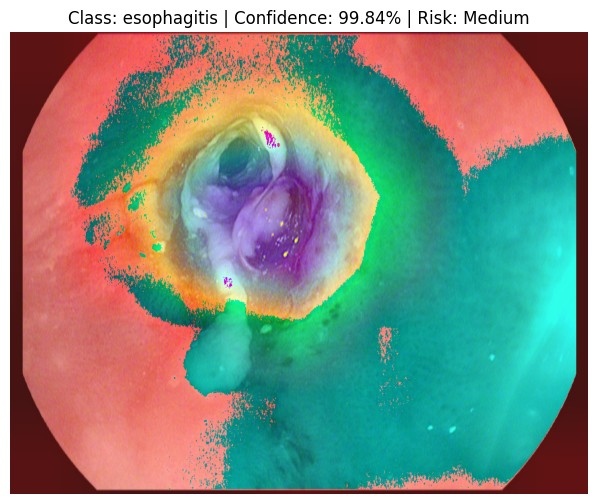

In [24]:
# Display the prediction result and Grad-CAM visualization for the selected image
show_result(img_path, model, class_names)

# **Lime** 

In [34]:
# Install the LIME library for model interpretability
!pip install lime

In [35]:
# Import LIME for generating image explanations
from lime import lime_image

# Import utility for visualizing explanation boundaries
from skimage.segmentation import mark_boundaries

# Import EfficientNet preprocessing function
from tensorflow.keras.applications.efficientnet import preprocess_input

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

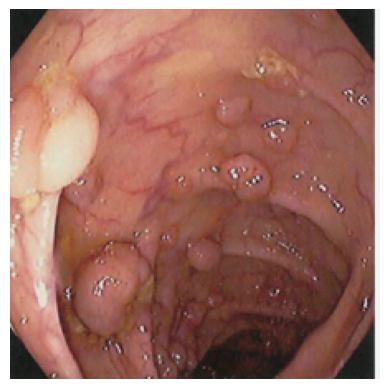

In [36]:
# Import the PIL library for image processing
from PIL import Image

# Load and resize the input image
img = Image.open("/kaggle/input/datasets/ranaahmed202201899/test-img/Screenshot 2026-05-02 130239.png").convert("RGB")
img = img.resize((224,224))

# Convert the image to a NumPy array
img_array = np.array(img)

# Display the image
plt.imshow(img_array)
plt.axis("off")

In [37]:
# Define a prediction function for LIME explanations
def predict_fn(images):

    # Convert input images to NumPy arrays
    images = np.array(images, dtype=np.float32)

    # Apply EfficientNet preprocessing
    images = preprocess_input(images)

    # Generate model predictions
    return model.predict(images, verbose=0)

In [38]:
# Create a LIME image explainer instance
explainer = lime_image.LimeImageExplainer()

In [39]:
# Generate a LIME explanation for the selected image
explanation = explainer.explain_instance(
    img_array,
    predict_fn,
    top_labels=1,
    hide_color=0,
    num_samples=1000
)

  0%|          | 0/1000 [00:00<?, ?it/s]

In [40]:
# Generate a LIME explanation using 2000 perturbed samples
num_samples=2000

In [41]:
# Extract the most influential regions identified by LIME
temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0],
    positive_only=True,
    num_features=10,
    hide_rest=False
)

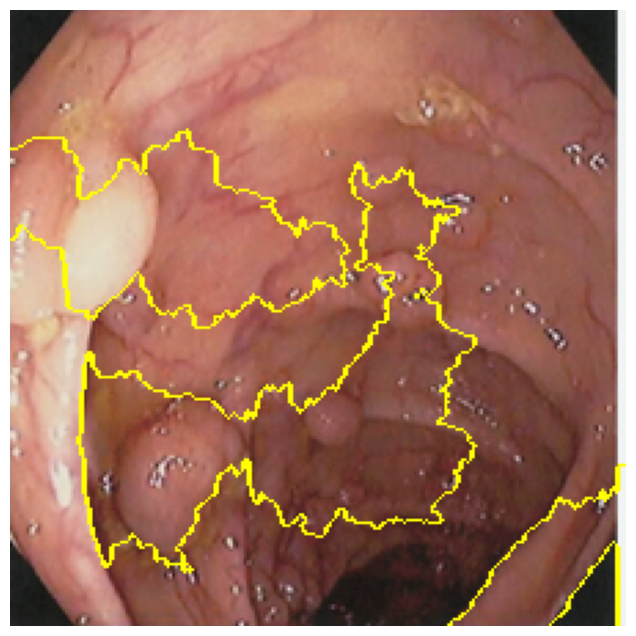

In [42]:
# Visualize the LIME explanation by highlighting important image regions
plt.figure(figsize=(8,8))

plt.imshow(
    mark_boundaries(
        temp / 255.0,
        mask
    )
)

# Hide axis labels and display the result
plt.axis("off")
plt.show()

# **Evaluations**

In [43]:
# Generate a prediction for the input image
pred = model.predict(
    preprocess_input(
        np.expand_dims(img_array, 0)
    )
)

# Get the index of the predicted class
pred_idx = np.argmax(pred)

# Display the predicted class and its confidence score
print(class_names[pred_idx])
print(pred[0][pred_idx])

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
polyps
0.99745697


In [44]:
# Evaluate the model on the test dataset
test_loss, test_acc = model.evaluate(test_ds)

# Display the test accuracy
print("Test Accuracy:", test_acc)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.8854 - loss: 0.3214
Test Accuracy: 0.8854166865348816


In [45]:
# Import the classification report metric
from sklearn.metrics import classification_report

# Initialize lists to store true and predicted labels
y_true = []
y_pred = []

# Generate predictions for the test dataset
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# Display the classification report for all classes
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

                        precision    recall  f1-score   support

    dyed-lifted-polyps       0.89      0.82      0.86        40
dyed-resection-margins       0.87      0.90      0.88        50
           esophagitis       0.97      0.67      0.79        45
          normal-cecum       0.93      0.95      0.94        44
        normal-pylorus       0.95      0.93      0.94        42
         normal-z-line       0.72      0.93      0.81        46
                polyps       0.95      0.91      0.93        65
    ulcerative-colitis       0.88      0.94      0.91        52

              accuracy                           0.89       384
             macro avg       0.89      0.88      0.88       384
          weighted avg       0.90      0.89      0.88       384



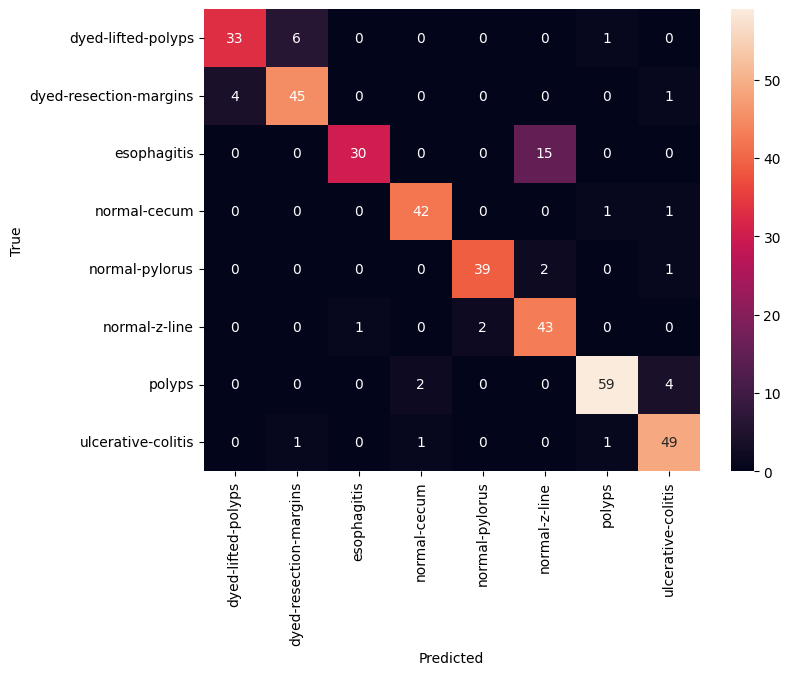

In [46]:
# Import libraries for confusion matrix visualization
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Generate the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Create a heatmap to visualize classification performance
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names
)

# Add axis labels
plt.xlabel("Predicted")
plt.ylabel("True")

# Display the confusion matrix
plt.show()

# **Download Model**

In [28]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb1 (Functional)     │ (None, 7, 7, 1280)     │     6,575,239 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,932,289 (64.59 MB)

 Trainable params: 5,010,968 (19.12 MB)

 Non-trainable params: 1,899,383 (7.25 MB)

 Optimizer params: 10,021,938 (38.23 MB)

In [29]:
from tensorflow.keras.models import Model
dummy = np.zeros((1, 224, 224, 3))
_ = model(dummy)   

In [30]:
# model.save("gi_model_fixed.h5")

In [31]:
for i, layer in enumerate(model.layers):
    print(i, layer.name)

0 sequential
1 lambda
2 efficientnetb1
3 global_average_pooling2d
4 batch_normalization
5 dense
6 dropout
7 dense_1


In [32]:
import tensorflow as tf

base = model.layers[2]

x = base.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dense(256, activation="relu")(x)
x = tf.keras.layers.Dropout(0.4)(x)
outputs = tf.keras.layers.Dense(8, activation="softmax")(x)

new_model = tf.keras.Model(inputs=base.input, outputs=outputs)

new_model.set_weights(model.get_weights())

In [33]:
new_model(np.zeros((1,224,224,3)))

new_model.save("gi_model_clean.h5")